# Energy-Based Gravitational Dominance in the Solar System

This notebook presents a computational analysis of gravitational dominance in planetary systems using an energy-based framework combined with Hill radius scaling.

The study extends a previous force-based formulation by expressing gravitational dominance in terms of gravitational potential energy rather than instantaneous force balance. This reformulation provides a more global description of energetic influence within planetary systems and distinguishes local force dominance from energetic binding conditions.

Earth, Mars, Jupiter, and the asteroid (101955) Bennu are analyzed to investigate how gravitational dominance varies across bodies spanning several orders of magnitude in mass.

The model evaluates the ratio between planetary and solar gravitational potentials as a function of distance normalized by the Hill radius, providing a comparative framework for examining gravitational environments across Solar System bodies.

**Author:** Ömür Çarboğa  
**Method:** Python numerical simulation  
**Year:** 2026

## Method Overview

The model estimates gravitational dominance by comparing the gravitational potential contributions associated with a celestial body and the Sun at the same location.

This formulation provides a global measure of relative energetic influence rather than a description based solely on instantaneous force balance.

Distances are expressed as fractions of the Hill radius, allowing gravitational environments with substantially different physical scales to be compared within a normalized framework. The simulation evaluates the energy ratio across a continuous range of distances and visualizes how energetic dominance varies for each body.

Units used in this simulation:

Distance = meters  
Mass = kilograms  
Hill radius = meters  
Plots = Hill radius units

### Gravitational Potential Ratio

The gravitational dominance metric used in this simulation is defined as the ratio between the gravitational potential contributions of a celestial body and the Sun evaluated at the same location.

The gravitational potential is given by:

U = -GM/r

Using this relation, the energy-based dominance ratio becomes:

S_E = |U_body| / |U_sun|

which can be written as:

S_E = (GM_body/r_body)/(GM_sun/r_sun)

When this ratio exceeds unity, the energetic influence of the celestial body becomes greater than that of the Sun at the sampled location. Unlike force-based measures, this formulation reflects the relative depth of gravitational potential wells rather than instantaneous gravitational acceleration.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

"""
PHYSICAL ASSUMPTIONS:

1. The solar gravitational potential is treated as approximately constant across the Hill sphere. This assumes that the particle distance from
   the celestial body (r) is much smaller than the orbital radius of the body (a), i.e., r << a.

2. Under this approximation, the particle–Sun distance is assumed to be approximately equal to the orbital radius (a). Therefore, the solar
   gravitational potential is computed as:

       U_sun = -G*M/a

3. This first-order approximation is valid within the Hill-sphere framework.

NOTE:
A more precise treatment would replace a with (a ± r), introducing spatial variation in the solar potential. However, within the Hill-radius
regime this correction remains small and is neglected to preserve a consistent normalized framework.
"""

"""
MODEL DESCRIPTION:

This simulation evaluates gravitational dominance using an energy-based approach by comparing the gravitational potential contribution associated
with a celestial body to that of the Sun.

The model:

- Computes energy ratios as a function of distance
- Represents relative energetic influence rather than instantaneous force balance
- Does NOT simulate trajectories or time evolution
- Does NOT solve the three-body problem

Therefore, the results represent energetic dominance transitions rather than exact dynamical or orbital stability boundaries.
"""

'\nMODEL DESCRIPTION:\n\nThis simulation evaluates gravitational dominance using an energy-based approach by comparing the gravitational potential contribution associated\nwith a celestial body to that of the Sun.\n\nThe model:\n\n- Computes energy ratios as a function of distance\n- Represents relative energetic influence rather than instantaneous force balance\n- Does NOT simulate trajectories or time evolution\n- Does NOT solve the three-body problem\n\nTherefore, the results represent energetic dominance transitions rather than exact dynamical or orbital stability boundaries.\n'

## Hill Radius Function

In [15]:
def hill_radius(a, m, M):
    """
    Calculates the Hill radius of a celestial body.

    The Hill radius defines the characteristic region surrounding a celestial body where its gravitational influence can dominate
    over perturbations from the central star. In this study, it serves as a normalization scale for comparing energetic dominance
    across systems with substantially different physical sizes.

    Parameters
    ----------
    a : float
        Orbital distance from the Sun (m)
    m : float
        Mass of the celestial body (kg)
    M : float
        Mass of the Sun (kg)

    Returns
    -------
    float
        Hill radius (m)
    """

    return a * (m / (3 * M)) ** (1/3)

### Hill Radius Definition

The Hill radius defines a characteristic region surrounding a celestial body where its gravitational influence can dominate over perturbations from the Sun, providing a natural scale for analyzing gravitational dominance.

It can be estimated using:

R_H = a ( m / (3M) )^(1/3)

where

a = orbital semi-major axis of the body  
m = mass of the body  
M = mass of the Sun  

This approximation is widely used in celestial mechanics as a characteristic scale for gravitational environments and satellite stability. In the present study, it serves primarily as a normalization parameter for comparing energetic dominance across systems with substantially different physical sizes.

## Physical Constants

In [16]:
# Physical Constants

G = 6.67430e-11        # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30       # mass of the Sun (kg)

# Planetary Data

jupiter_mass = 1.898e27      # kg
jupiter_orbit = 7.78e11      # m

earth_mass = 5.972e24        # kg
earth_orbit = 1.496e11       # m

mars_mass = 6.39e23          # kg
mars_orbit = 2.279e11        # m

# Asteroid Data

bennu_mass = 7.8e10          # kg
bennu_orbit = 1.68e11        # m

# NOTE:
# Bennu possesses an extremely small mass compared to planetary bodies.
# Consequently, its Hill radius and energetic dominance region are expected
# to be highly limited.
#
# This provides an extreme comparison case illustrating how energetic
# dominance depends strongly on body mass and gravitational potential depth.

## Celestial Body Data

In [17]:
# Body database structure:
# {name: (mass, orbital distance, Hill radius)}

bodies = {
    "Jupiter": (
        jupiter_mass,
        jupiter_orbit,
        hill_radius(jupiter_orbit, jupiter_mass, M_sun)
    ),

    "Earth": (
        earth_mass,
        earth_orbit,
        hill_radius(earth_orbit, earth_mass, M_sun)
    ),

    "Mars": (
        mars_mass,
        mars_orbit,
        hill_radius(mars_orbit, mars_mass, M_sun)
    ),

    "Bennu": (
        bennu_mass,
        bennu_orbit,
        hill_radius(bennu_orbit, bennu_mass, M_sun)
    )
}

## Hill Radius Calculations

In [18]:
# Compute Hill radii used as normalization scales

jupiter_hill = hill_radius(jupiter_orbit, jupiter_mass, M_sun)
earth_hill = hill_radius(earth_orbit, earth_mass, M_sun)
mars_hill = hill_radius(mars_orbit, mars_mass, M_sun)
bennu_hill = hill_radius(bennu_orbit, bennu_mass, M_sun)

# Display Hill radius values for each analyzed body

for name, (mass, orbit, hill) in bodies.items():
    print(f"{name} Hill Radius (normalization scale): {hill:.2e} m")

Jupiter Hill Radius (normalization scale): 5.31e+10 m
Earth Hill Radius (normalization scale): 1.50e+09 m
Mars Hill Radius (normalization scale): 1.08e+09 m
Bennu Hill Radius (normalization scale): 3.96e+04 m


### Interpretation

The calculated Hill radii provide characteristic scales for regions where the gravitational influence of each body can dominate over solar perturbations.

More massive bodies exhibit larger Hill radii, corresponding to deeper gravitational potential wells and broader regions of potential energetic influence. These differences illustrate how gravitational dominance varies across systems spanning several orders of magnitude in mass.

The Hill-radius scaling obtained here will be used to normalize distances in the subsequent analysis.

## Hill Radius Scale Comparison

To illustrate the large differences in gravitational scaling between celestial bodies, the Hill radius of each body is compared directly.

This visualization highlights how planetary bodies possess substantially larger characteristic scales than small asteroids such as Bennu. These differences reflect variations in gravitational potential depth and the spatial extent over which energetic influence may become significant.

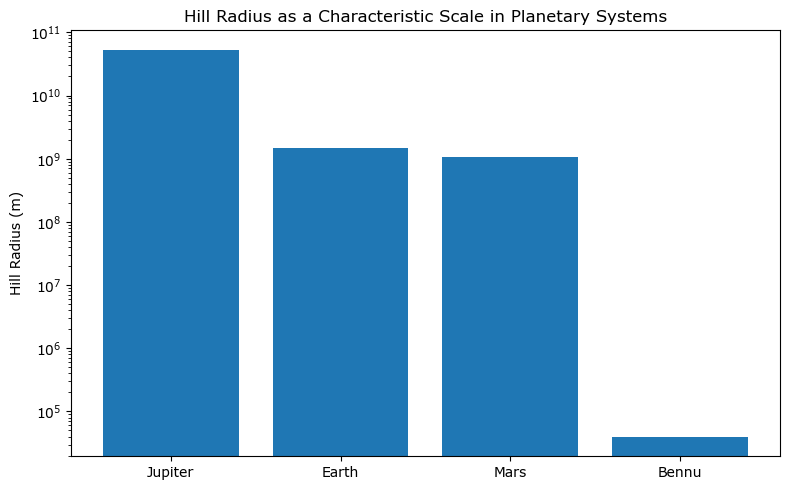

In [19]:
# Hill radius comparison across analyzed bodies

objects = ["Jupiter", "Earth", "Mars", "Bennu"]

hill_values = [
    jupiter_hill,
    earth_hill,
    mars_hill,
    bennu_hill
]

plt.figure(figsize=(8, 5))

plt.bar(objects, hill_values)

plt.title("Hill Radius as a Characteristic Scale in Planetary Systems")
plt.ylabel("Hill Radius (m)")

# Logarithmic scaling is used because Hill radii span multiple orders of magnitude

plt.yscale("log")

plt.tight_layout()

plt.savefig("hill_radius.png")

plt.show()

### Interpretation

The figure shows that Jupiter possesses the largest Hill radius among the analyzed bodies, followed by Earth and Mars.

This trend reflects the strong scaling dependence of the Hill radius on body mass, with more massive planets exhibiting substantially larger characteristic gravitational scales.

In contrast, the asteroid Bennu possesses an extremely small Hill radius, indicating a highly limited spatial region in which its gravitational potential can become energetically significant relative to the Sun.

## Orbital Stability Analysis

In [20]:
# Energy Ratio Function
#
# This function calculates the ratio between the gravitational potential
# contribution associated with a celestial body and that associated with
# the Sun at a radial distance r.
#
# S_E > 1  → energetic influence of the body exceeds that of the Sun
# S_E ≈ 1  → approximate energetic transition region
# S_E < 1  → solar gravitational potential dominates
#
# In the numerical analysis, a small tolerance is used when detecting
# transition points because floating-point calculations rarely produce
# values exactly equal to unity.

def energy_ratio(r, m_planet, M_sun, a_planet, G):
    """
    Computes the ratio between the gravitational potential contributions
    of a celestial body and the Sun at a distance r from the body.

    Parameters
    ----------
    r : float
        Distance from the body (m)
    m_planet : float
        Mass of the body (kg)
    M_sun : float
        Mass of the Sun (kg)
    a_planet : float
        Orbital distance of the body from the Sun (m)
    G : float
        Gravitational constant

    Returns
    -------
    float
        Energy ratio (|U_body| / |U_sun|)
    """

    U_body = -G * m_planet / r
    U_sun = -G * M_sun / a_planet

    return abs(U_body) / abs(U_sun)

## Model Assumptions

This computational model evaluates gravitational dominance using a simplified energetic framework under several assumptions:

• The Sun–body system is treated as an isolated two-body system.  
• Perturbations from other planetary bodies are neglected.  
• Test particles are assumed to possess negligible mass.  
• Circular orbits are assumed for the analyzed bodies.  

These assumptions enable a simplified analysis of energetic dominance regions, providing a static energetic approximation rather than a complete dynamical treatment of orbital evolution or long-term stability.

## Test Distances

In [21]:
# Normalized radial distances sampled in units of the Hill radius

r_scaled = np.linspace(0.01, 2.0, 2000)

### Radial Sampling Domain

The normalized radial coordinate `x` represents distance expressed in units of the Hill radius.

Distances are sampled from **0.01 to 2 Hill radii** using 2000 evenly spaced points.  
This range allows the simulation to evaluate gravitational dominance both within and slightly beyond the Hill-radius regime.

Sampling this interval provides a continuous numerical profile of how energetic dominance varies with distance from the celestial body.

### Simulation Method

This simulation analyzes gravitational dominance around celestial bodies using the Hill-radius framework.

The model compares gravitational potential contributions from the celestial body and the Sun at different radial distances.

The gravitational dominance metric is defined as:

S_E = |U_body| / |U_sun|

Distances are expressed in units of the Hill radius. The energetic transition region is defined as the location where the energy ratio approaches unity, indicating comparable energetic influence between the Sun and the analyzed body.

Note: The energy-ratio threshold used in this simulation represents a simplified indicator of gravitational dominance. It should not be interpreted as a precise orbital stability boundary. True orbital stability is governed by the dynamical behavior of the Restricted Three-Body Problem.

Bodies analyzed in this simulation:

• Jupiter  
• Earth  
• Mars  
• Asteroid (101955) Bennu

In [22]:
# MODEL LIMITATION NOTE
#
# This simulation evaluates an energy-based ratio between the Sun and a
# celestial body as a simplified indicator of gravitational dominance.
#
# The model does NOT compute full orbital stability solutions.
# Real orbital stability is governed by the dynamical behavior of the
# Restricted Three-Body Problem.

results = {}

for name, (mass, orbit, hill) in bodies.items():

    # Convert normalized distances to physical distances

    r = r_scaled * hill

    # Energy-based gravitational dominance ratio

    S_E = (mass / M_sun) * (orbit / r)

    results[name] = S_E

### Gravitational Dominance Transition Detection

To estimate energetic dominance transitions, the simulation identifies radial locations where the gravitational potential contributions associated with the celestial body and the Sun approach equality.

This occurs when the energy ratio satisfies:

S_E = |U_body| / |U_sun| = 1

At this transition point, both gravitational sources contribute comparably in an energetic sense. Beyond this distance, the solar gravitational potential becomes dominant.

The algorithm therefore searches for the first location where the computed energy ratio approaches unity. A small numerical tolerance is applied to minimize floating-point precision effects during transition detection.

In [23]:
# Finds the approximate location where the energy ratio approaches and crosses unity.

def find_dominance_transition_radius(r_scaled, ratios):
    """
    Identifies the approximate radial location where the energy ratio
    (S_E) transitions from values greater than unity to values near or
    below unity.

    A small numerical tolerance is applied to reduce floating-point
    precision effects.

    Returns the distance in Hill-radius units.
    """

    tolerance = 1e-6

    for i in range(1, len(ratios)):

        if ratios[i] <= 1 + tolerance and ratios[i - 1] > 1 + tolerance:
            return r_scaled[i]

    return None

In [24]:
# Store energetic dominance transition locations for each body

transition_points = {}

for name, ratios in results.items():

    transition = find_dominance_transition_radius(r_scaled, ratios)

    transition_points[name] = transition

In [25]:
for body, transition in transition_points.items():

    if transition is None:
        print(f"{body}: No energetic dominance transition detected within the sampled range")

    else:
        print(f"{body} transition radius ≈ {round(transition, 3)} R_H")

Jupiter transition radius ≈ 0.014 R_H
Earth: No energetic dominance transition detected within the sampled range
Mars: No energetic dominance transition detected within the sampled range
Bennu: No energetic dominance transition detected within the sampled range


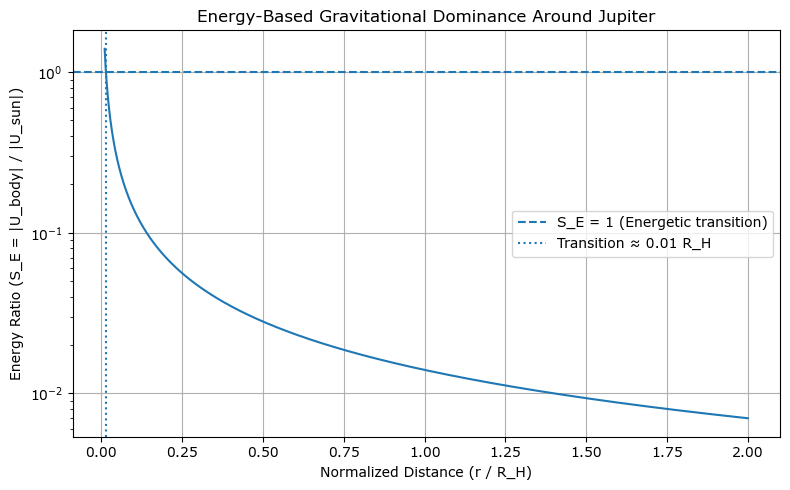

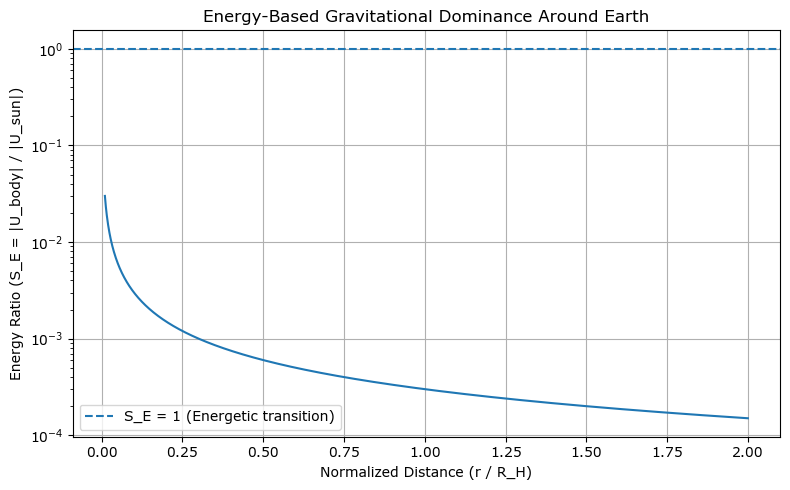

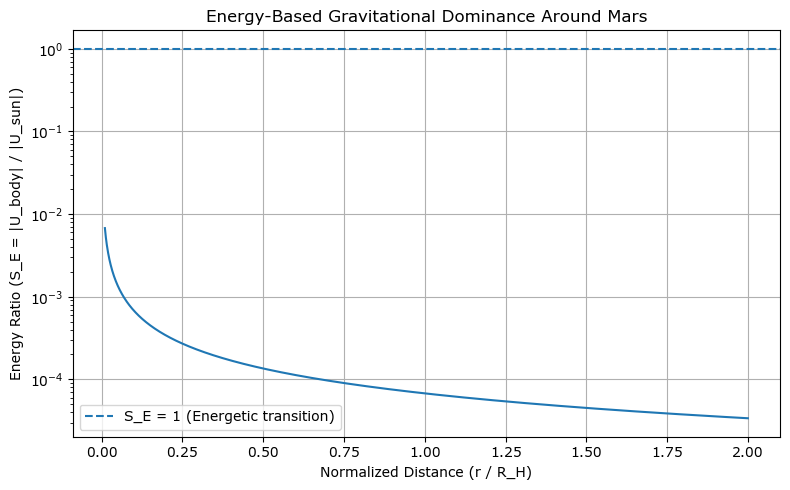

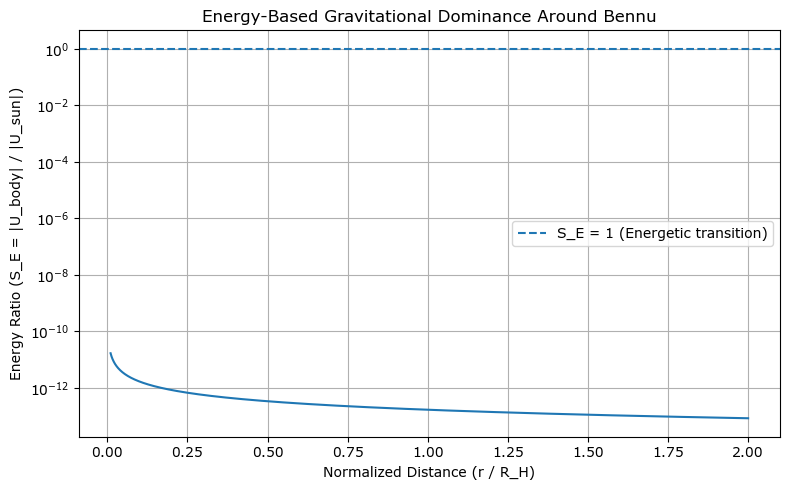

In [26]:
import matplotlib.pyplot as plt

for name, ratios in results.items():

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(r_scaled, ratios)

    ax.axhline(
        1,
        linestyle="--",
        label="S_E = 1 (Energetic transition)"
    )

    transition = transition_points[name]

    if transition is not None:

        ax.axvline(
            transition,
            linestyle=":",
            label=f"Transition ≈ {transition:.2f} R_H"
        )

    ax.set_yscale("log")

    ax.set_xlabel("Normalized Distance (r / R_H)")
    ax.set_ylabel("Energy Ratio (S_E = |U_body| / |U_sun|)")

    ax.set_title(
        f"Energy-Based Gravitational Dominance Around {name}"
    )

    ax.grid(True)

    ax.legend()

    plt.tight_layout()

    fig.savefig(f"{name}_energy_plot.png", dpi=300)

    plt.show()  

In [27]:
import pandas as pd

# Construct summary table of Hill radii and energetic transition locations

rows = []

for name, (mass, orbit, hill) in bodies.items():

    transition = transition_points[name]

    rows.append({
        "Body": name,
        "Hill Radius (m)": hill,
        "Hill Radius (km)": hill / 1000,
        "Transition Radius (R_H)": (
            round(transition, 3)
            if transition is not None
            else "No transition detected"
        )
    })

df = pd.DataFrame(rows)

df.index = df.index + 1
df.index.name = "No."

df

,Body,Hill Radius (m),Hill Radius (km),Transition (R_H)
No.,,,,
1,Jupiter,5.310796e+10,5.310796e+07,0.014
2,Earth,1.496418e+09,1.496418e+06,No transition
3,Mars,1.082246e+09,1.082246e+06,No transition
4,Bennu,3.957511e+04,3.957511e+01,No transition


## Energetic Dominance Comparison

The figure below compares the energetic dominance profiles of each body as a function of distance normalized by its Hill radius.

The vertical axis represents the energy ratio:

S_E = |U_body| / |U_sun|

Values greater than unity indicate that the gravitational potential associated with the body exceeds that of the Sun in an energetic sense, corresponding to stronger local energetic influence.

The dashed reference lines indicate:

• r / R_H = 1 (Hill-radius scaling)  
• S_E = 1 (equal energetic influence)  

This comparison illustrates how different celestial bodies exhibit distinct energetic dominance behaviors while also highlighting the effectiveness of Hill-radius normalization in placing systems with vastly different masses onto a comparable scale.

As a result, bodies spanning several orders of magnitude in mass can be analyzed within a unified energetic framework.

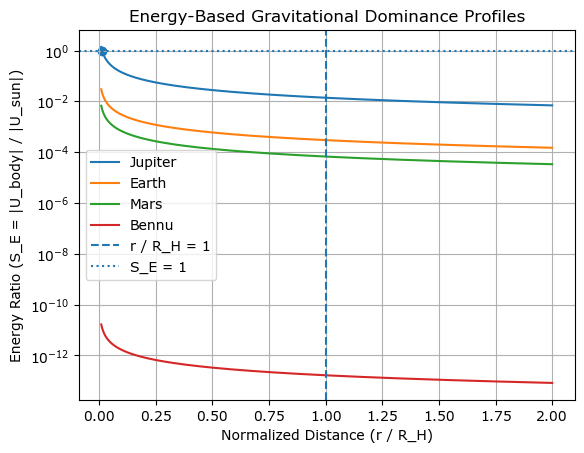

In [28]:
plt.figure(figsize=(8, 5))

# Plot energetic dominance profiles

for name, ratios in results.items():

    plt.plot(r_scaled, ratios, label=name)

# Plot detected energetic transition locations

for body, transition in transition_points.items():

    if transition is not None:

        plt.scatter(transition, 1)

# Reference lines

plt.axvline(
    1,
    linestyle="--",
    label="r / R_H = 1"
)

plt.axhline(
    1,
    linestyle=":",
    label="S_E = 1"
)

plt.yscale("log")

plt.xlabel("Normalized Distance (r / R_H)")

plt.ylabel(
    "Energy Ratio (S_E = |U_body| / |U_sun|)"
)

plt.title(
    "Energy-Based Gravitational Dominance Profiles"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "comparative_energy_profiles.png",
    dpi=300
)

plt.show()

### Energetic Transition Visualization

The horizontal dotted line represents the condition at which the gravitational potential contributions associated with the celestial body and the Sun become equal, corresponding to:

S_E = 1

At this level, both gravitational sources contribute equally in an energetic sense. Values greater than unity indicate that the gravitational potential associated with the body exceeds that of the Sun locally.

Circular markers indicate the approximate locations where energetic dominance transitions occur for each body, illustrating how the transition behavior scales across systems with substantially different masses.

## Quantitative Results

The table below summarizes the principal numerical results produced by the computational model, including Hill-radius size and the detected energetic dominance transition for each analyzed body.

In [29]:
print("Body | Hill Radius (km) | Transition Radius (R_H) | Transition Radius (km)")
print("-----------------------------------------------------------------------")

for name, (mass, orbit, hill) in bodies.items():

    hill_km = hill / 1000

    transition_hr = transition_points[name]

    if transition_hr is not None:

        transition_km = transition_hr * hill_km

        print(
            f"{name} | "
            f"{round(hill_km, 2)} | "
            f"{round(transition_hr, 3)} | "
            f"{round(transition_km, 2)}"
        )

    else:

        print(
            f"{name} | "
            f"{round(hill_km, 2)} | "
            f"No transition (within 2 R_H) | "
            f"No transition (within 2 R_H)"
        )

Body | Hill Radius (km) | Transition (R_H) | Transition (km)
-------------------------------------------------------------
Jupiter | 53107964.19 | 0.014 | 742555.08
Earth | 1496417.74 | No transition (within 2 R_H) | No transition (within 2 R_H)
Mars | 1082245.86 | No transition (within 2 R_H) | No transition (within 2 R_H)
Bennu | 39.58 | No transition (within 2 R_H) | No transition (within 2 R_H)


### Interpretation of Energetic Transition Behavior

Among the analyzed bodies, only Jupiter exhibits an energetic dominance transition within the sampled interval of 0.01–2 Hill radii.

For Jupiter, the energy ratio S_E exceeds unity at sufficiently small normalized distances before decreasing below the transition threshold as distance increases. This behavior indicates the existence of a localized region in which Jupiter’s gravitational potential contribution becomes energetically greater than that of the Sun.

In contrast, Earth, Mars, and the asteroid Bennu remain below the threshold value throughout the sampled domain. Although their energy ratios increase toward smaller radial distances, they do not reach unity within the evaluated interval.

This result illustrates how the energy-based formulation produces substantially different dominance behavior across bodies with different masses. In particular, the emergence of a detectable energetic transition depends strongly on the depth of the gravitational potential well associated with the analyzed body.

## Comparison with Real Satellite Systems

The results can be qualitatively compared with known satellite systems in the Solar System.

Major moons typically orbit well inside their planet's Hill radius.  
For example, the Galilean moons of Jupiter occupy only a small fraction of Jupiter's Hill sphere.

This behavior is broadly consistent with the simulation results, where the energetic dominance transition detected for Jupiter occurs within the Hill-radius scale rather than exactly at its outer boundary.

The model suggests that regions in which a planet’s gravitational potential becomes energetically significant relative to the Sun are generally concentrated toward the inner portion of the Hill-radius regime.

At the same time, the results show that smaller bodies such as Earth, Mars, and the asteroid Bennu do not exhibit a detected energetic transition within the sampled interval of 0.01–2 Hill radii. This highlights the strong dependence of the energy-based formulation on gravitational potential depth and body mass.

The model therefore provides a simplified energetic interpretation of why massive planets can maintain extensive satellite systems, while very small bodies possess substantially more limited regions of gravitational influence. In this framework, the Hill radius serves primarily as a comparative scaling parameter rather than a precise boundary for gravitational binding or orbital stability.

## Discussion

The results highlight the strong dependence of gravitational influence on body mass when interpreted through an energy-based framework. More massive bodies generate deeper gravitational potential wells, allowing their gravitational contributions to become energetically significant relative to the Sun over localized spatial regions.

Among the analyzed systems, Jupiter exhibits the only clear energetic dominance transition within the sampled interval. Due to its large mass, the energy ratio exceeds unity at sufficiently small normalized distances before decreasing below the transition threshold with increasing radius. Although Jupiter possesses the largest Hill radius in the study, the transition occurs within only a fraction of this scale, indicating that energetic dominance remains concentrated toward the inner region of the Hill-radius regime rather than extending across the entire Hill sphere.

In contrast, Earth and Mars do not exhibit an energetic dominance transition within the evaluated interval of 0.01–2 Hill radii. Their energy ratios remain below unity throughout the sampled domain, indicating that the solar gravitational potential contribution remains energetically greater within the limits of the present framework.

The asteroid Bennu represents the extreme low-mass case. Its energy ratio remains several orders of magnitude below unity across the entire sampled interval, with no indication of a detectable transition. This behavior reflects the highly limited energetic influence associated with very small bodies in comparison with planetary systems.

Overall, the comparison demonstrates that Hill-radius normalization provides an effective geometric scaling framework, but does not produce a universal energetic structure across systems with substantially different masses. The emergence of an energetic dominance region depends strongly on gravitational potential depth and system mass.

At the same time, both the Hill radius and the associated energy-based transition should be interpreted as approximate indicators of gravitational influence rather than precise dynamical stability boundaries. True orbital stability in a three-body system depends on time-dependent dynamics, including velocity evolution, resonant interactions, and external perturbations, none of which are captured in the present static energetic model.

## Model Limitations

This analysis employs a simplified energy-based framework to approximate regions of gravitational dominance within the Hill-radius regime.

The model does not perform full orbital integrations or solve the Restricted Three-Body Problem. Consequently, the identified transition locations (defined by S_E = 1) should be interpreted as approximate indicators of energetic dominance rather than precise dynamical stability boundaries.

The present formulation is static and does not include velocity evolution, time-dependent dynamics, resonant interactions, or perturbations from additional bodies.

Furthermore, the solar gravitational potential is treated using a first-order approximation in which the particle–Sun distance is assumed to remain approximately equal to the orbital radius of the analyzed body. While this approximation is generally reasonable within the Hill-radius regime, it neglects higher-order spatial variations in the solar potential.

More advanced investigations would require numerical N-body simulations capable of tracking the long-term evolution of particle trajectories and capturing the full dynamical behavior of gravitational systems.

## Implications for Spacecraft Dynamics

Understanding regions of gravitational influence is fundamentally important in spacecraft trajectory design and mission planning. Spacecraft operating near planets, moons, or small bodies experience competing gravitational contributions from both the local body and the Sun, producing complex dynamical environments that strongly affect orbital behavior.

Within the Hill-radius regime of a massive planet, there can exist localized regions where the planetary gravitational potential becomes energetically greater than that of the Sun (S_E > 1). In such regions, spacecraft and natural satellites may remain more strongly associated with the planet in an energetic sense, although this condition alone does not guarantee long-term orbital stability. Real mission dynamics additionally depend on velocity, orbital geometry, resonances, and perturbative interactions.

The results of the present model suggest that energetic dominance regions become increasingly limited for lower-mass bodies. In the simulations, only Jupiter exhibits a detectable energetic transition within the sampled interval, while Earth, Mars, and Bennu remain below the transition threshold. This illustrates how the depth of the gravitational potential well strongly influences the extent of localized gravitational control.

For small bodies such as asteroids, the combination of extremely small mass and limited Hill-radius scale causes solar perturbations to remain dynamically important across much of the surrounding environment. As a result, spacecraft missions near asteroids often encounter unstable or weakly bound dynamical conditions.

This behavior is consistent with real asteroid missions, which frequently rely on station-keeping maneuvers, controlled hovering trajectories, quasi-satellite motion, or repeated orbital corrections rather than long-duration stable Keplerian orbits. In such environments, even small perturbations from solar gravity, solar radiation pressure, or irregular body shape can significantly alter spacecraft trajectories over time.

From an aerospace engineering perspective, simplified energetic models such as the present framework may help provide intuitive insight into how gravitational environments scale across different planetary systems. Although the model does not replace full dynamical simulations, it offers a computationally accessible method for comparing relative gravitational influence and estimating how spacecraft operating conditions may vary between massive planets and very small bodies.

## Conclusion

This computational analysis investigated how gravitational dominance varies with distance from a celestial body by comparing the gravitational potential contributions associated with the body and the Sun. Using Hill-radius normalization, the simulation examined how energetic dominance behavior scales across systems spanning several orders of magnitude in mass.

The results demonstrate a strong dependence of energetic dominance on gravitational potential depth and body mass. Among the analyzed systems, only Jupiter exhibits a detectable energetic dominance transition within the sampled interval of 0.01–2 Hill radii. In this case, the energy ratio exceeds unity at sufficiently small normalized distances before decreasing below the transition threshold with increasing radius.

In contrast, Earth, Mars, and the asteroid (101955) Bennu remain below the threshold condition throughout the sampled domain, indicating that the solar gravitational potential contribution remains energetically greater within the limits of the present framework. Bennu represents the extreme low-mass case, exhibiting especially weak energetic influence relative to the Sun.

Overall, the analysis shows that the Hill radius provides a useful geometric scaling parameter, while the energy-based formulation offers a complementary perspective on gravitational influence in planetary systems. At the same time, the results emphasize that Hill-radius scaling alone does not produce a universal energetic structure across bodies with substantially different masses.

Although simplified, the present framework provides an accessible computational approach for comparing gravitational environments across planetary and small-body systems while illustrating the strong relationship between body mass, gravitational potential depth, and energetic dominance behavior.